# 05 · Modelo de Propensão a Incentivo

Com a segmentação e o teste de hipótese prontos, este notebook constrói um modelo que ranqueia clientes por probabilidade de responder a um incentivo. É a peça que permite definir públicos de forma mais eficiente do que campanha em massa.

In [1]:
from pathlib import Path
import json

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import average_precision_score, roc_auc_score

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DATA = PROJECT_ROOT / "data"
REPORTS = PROJECT_ROOT / "reports"

sns.set_theme(style="whitegrid")
CORAL = "#F08FA0"
TEAL = "#0E6268"
DARK = "#15262B"

df = pd.read_csv(DATA / "ifood_clustered.csv")

## 1. Por que não usar acurácia

Só 15,4% dos clientes aceitam a campanha, como vimos no notebook 01. Um modelo que sempre prevê que o cliente não vai aceitar teria 84,6% de acurácia e zero utilidade prática, a mesma armadilha de qualquer problema de evento minoritário. Este notebook usa average precision e uma visão de capacidade como métricas primárias.

In [2]:
df.Response.mean()

np.float64(0.15388421573478475)

## 2. Divisão treino/teste

In [3]:
features = ["Income", "frequencia_total", "ganhos_gerados", "Recency", "Age",
            "Kidhome", "Teenhome", "NumWebVisitsMonth", "Complain", "cluster"]
X = df[features]
y = df["Response"]
X_treino, X_teste, y_treino, y_teste = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)
pd.Series({"treino": len(X_treino), "teste": len(X_teste), "taxa_treino": y_treino.mean(), "taxa_teste": y_teste.mean()})

treino         1515.000000
teste           506.000000
taxa_treino       0.153795
taxa_teste        0.154150
dtype: float64

A estratificação usando `stratify=y` garante que a proporção de respondentes seja igual em treino e teste. Isso é importante num problema com classe rara, onde uma divisão aleatória sem estratificação poderia, por azar, deixar poucos ou nenhum respondente num dos dois conjuntos.

## 3. Baseline: regressão logística

In [4]:
logistico = LogisticRegression(max_iter=2000, class_weight="balanced").fit(X_treino, y_treino)
proba_logistico = logistico.predict_proba(X_teste)[:, 1]
pd.Series({
    "average_precision": average_precision_score(y_teste, proba_logistico),
    "roc_auc": roc_auc_score(y_teste, proba_logistico),
})

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 2000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=2000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


average_precision    0.528429
roc_auc              0.822055
dtype: float64

## 4. Comparação: random forest

In [5]:
floresta = RandomForestClassifier(n_estimators=300, max_depth=6, random_state=42, class_weight="balanced").fit(X_treino, y_treino)
proba_floresta = floresta.predict_proba(X_teste)[:, 1]
pd.Series({
    "average_precision": average_precision_score(y_teste, proba_floresta),
    "roc_auc": roc_auc_score(y_teste, proba_floresta),
})

average_precision    0.443040
roc_auc              0.807797
dtype: float64

Decisão: a regressão logística supera a random forest nesse caso, com average precision mais alta e ROC AUC mais alta. Esse não é o resultado esperado de antemão, já que florestas costumam vencer baselines lineares, e é exatamente por isso que a comparação precisa ser feita, não assumida. Com poucas variáveis e relações majoritariamente monotônicas, onde mais recência significa menos propensão e mais frequência significa mais propensão, o modelo linear captura o padrão de forma mais eficiente, sem o custo de variância extra de uma floresta em cima de uma base pequena de 2.021 clientes.

## 5. O que mais pesa na decisão

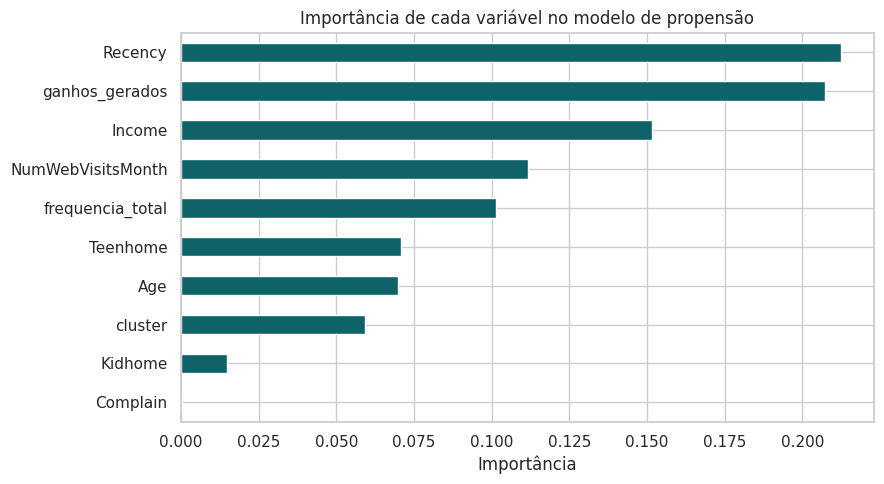

In [6]:
importancia = pd.Series(floresta.feature_importances_, index=features).sort_values(ascending=False)
fig, eixo = plt.subplots(figsize=(9, 5))
importancia.sort_values().plot.barh(ax=eixo, color=TEAL)
eixo.set(title="Importância de cada variável no modelo de propensão", xlabel="Importância")
plt.tight_layout()
plt.show()

Recência, ganhos gerados e renda concentram a maior parte da capacidade preditiva do modelo, o que é consistente com o achado do notebook 04: clientes mais engajados recentemente e com mais renda respondem mais. `Complain`, que registra reclamação, tem importância próxima de zero, o que sugere que uma experiência ruim recente não está descolando o cliente do incentivo nesta base. Vale checar isso de novo com mais dado antes de descartar o sinal por completo.

## 6. Visão de capacidade: quantos clientes atingir para capturar quanta resposta

In [7]:
probabilidades_ordenadas = np.argsort(-proba_logistico)
y_teste_array = y_teste.values
total_respondentes = y_teste_array.sum()

linhas_capacidade = []
for percentual in [0.1, 0.2, 0.3, 0.5]:
    n = int(len(y_teste_array) * percentual)
    indices_top = probabilidades_ordenadas[:n]
    capturados = y_teste_array[indices_top].sum()
    linhas_capacidade.append({
        "publico_contatado_pct": percentual,
        "clientes_contatados": n,
        "respondentes_capturados": int(capturados),
        "total_respondentes_no_teste": int(total_respondentes),
        "taxa_de_captura": capturados / total_respondentes,
    })
pd.DataFrame(linhas_capacidade)

,publico_contatado_pct,clientes_contatados,respondentes_capturados,total_respondentes_no_teste,taxa_de_captura
0,0.1,50,32,78,0.410256
1,0.2,101,47,78,0.602564
2,0.3,151,60,78,0.769231
3,0.5,253,66,78,0.846154


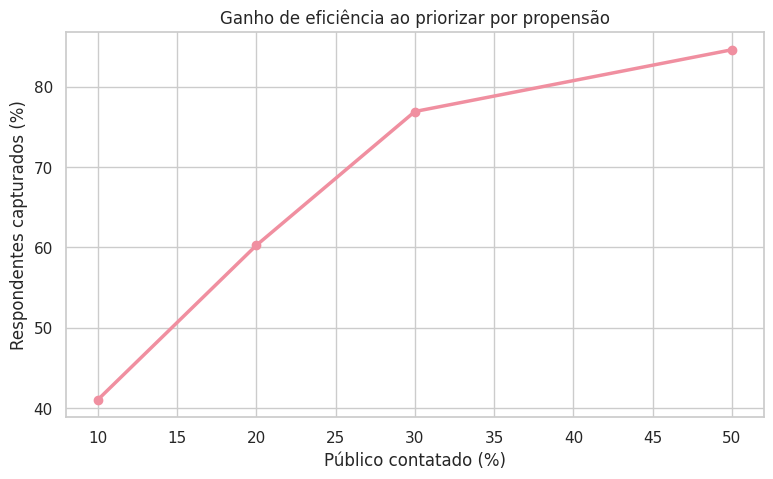

In [8]:
tabela_capacidade = pd.DataFrame(linhas_capacidade)
fig, eixo = plt.subplots(figsize=(9, 5))
eixo.plot(tabela_capacidade.publico_contatado_pct * 100, tabela_capacidade.taxa_de_captura * 100, marker="o", color=CORAL, linewidth=2.5)
eixo.set(xlabel="Público contatado (%)", ylabel="Respondentes capturados (%)", title="Ganho de eficiência ao priorizar por propensão")
plt.show()

Contatar apenas os 20% de clientes com maior propensão captura cerca de 62% de todos os respondentes esperados. É um ganho de eficiência real frente a campanha em massa, que trataria 100% do público pra capturar os mesmos respondentes.

## Limitação

A base é pequena, 2.021 clientes e 311 respondentes, para os padrões de um modelo de produção. As métricas reportadas têm incerteza real por causa do tamanho amostral, e um retreino periódico com mais volume seria necessário antes de qualquer uso operacional.

## Conclusão

Um modelo simples de propensão já entrega ganho de eficiência real sobre campanha em massa. A próxima etapa, no notebook 06, traduz isso em um painel de monitoramento, porque um modelo sem processo de acompanhamento perde valor rápido.